# Cross-Dataset Comparison: Privacy-Utility Trade-off Analysis

This notebook generates comparative visualizations across all datasets and DP models.

**Datasets:**

| Dataset | N | Features |
|---|---|---|
| Breast Cancer (BCP) | 569 | 30 |
| Diabetes (BRFSS 2015) | 70,692 | 21 |
| Cancer Risk | 1,500 | 8 |
| Gallstone | 319 | 38 |
| Kidney Stone | 4,000 | 23 |
| Lung Cancer | 50,000 | 23 |

**Models:** DP-RF, DP-LR, DP-GNB, DP-SVM, DP-DNN  
**Primary Metric:** ACL (Accuracy Loss) = 1 − Accuracy(M,ε) / Accuracy(M,ε=∞)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

# Publication-quality settings (IEEE/Nature style)
plt.rcParams.update({
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'Computer Modern Roman'],
    'font.size': 9,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'legend.fontsize': 7.5,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#333333',
    'axes.linewidth': 0.8,
    'grid.linewidth': 0.4,
    'lines.linewidth': 1.2,
    'lines.markersize': 4,
    'xtick.major.width': 0.6,
    'ytick.major.width': 0.6,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'legend.framealpha': 0.9,
    'legend.edgecolor': '#cccccc',
    'figure.constrained_layout.use': True,
    'mathtext.fontset': 'cm',
})

BASE_DIR = Path('..').resolve()
print(f"Base directory: {BASE_DIR}")

Base directory: /Users/amar/Desktop/Cybermac Course Materials/Publication/Architecture Resillience Manuscript/code/Results


## 1. Data Loading

Loads `consolidated_data.csv` (generated by `prepare_data.py`) — the canonical
cross-dataset results table: one row per (dataset, model, variant, epsilon).

Run `python prepare_data.py` first if the CSV does not exist.


In [2]:
# Load consolidated results (CSV is the canonical source; see Results/README.md)
DATA_FILE = Path('consolidated_data.csv')
if not DATA_FILE.exists():
    raise FileNotFoundError(
        "consolidated_data.csv not found. Run: python prepare_data.py"
    )

FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

df_raw = pd.read_csv(DATA_FILE)

# Baselines and DP runs live in the same table, distinguished by `variant`.
df_base = df_raw[df_raw['variant'] == 'standard'].copy()
df_all = df_raw[df_raw['variant'] == 'dp'].copy()

df_all = df_all.rename(columns={'accuracy_mean': 'accuracy', 'f1_score_mean': 'f1_score',
                                'precision_mean': 'precision', 'recall_mean': 'recall'})

# Dataset facts come from the table itself rather than a hardcoded dict.
DATASET_N_SAMPLES = df_raw.groupby('dataset')['n_samples'].first().to_dict()
DATASET_FEATURES = df_raw.groupby('dataset')['n_features'].first().to_dict()

datasets_all = sorted(df_raw['dataset'].unique(), key=lambda d: DATASET_N_SAMPLES[d])
models_all = sorted(df_all['model'].unique())
epsilons_all = sorted(df_all['epsilon'].dropna().unique())

print(f"Source: {DATA_FILE}  ({len(df_raw)} rows)")
print(f"Datasets: {datasets_all}")
print(f"Models: {models_all}")
print(f"Epsilon values: {epsilons_all}")
print(f"DP records: {len(df_all)}, Baselines: {len(df_base)}")

# Dataset summary table
print("\n" + "=" * 52)
print(f"  {'Dataset':<20s}  {'N':>7s}  {'Features':>8s}")
print("-" * 52)
for ds in datasets_all:
    print(f"  {ds:<20s}  {DATASET_N_SAMPLES[ds]:>7,}  {DATASET_FEATURES[ds]:>8}")
print("=" * 52)

print(f"\nDataset x Model combinations:")
print(df_all.groupby(['dataset', 'model']).size().unstack(fill_value=0))


Source: consolidated_data.csv  (444 rows)
Datasets: ['Gallstone', 'Breast Cancer', 'Cancer Risk', 'Kidney Stone', 'Lung Cancer', 'Diabetes']
Models: ['DP-DNN', 'DP-GNB', 'DP-LR', 'DP-RF', 'DP-SVM']
Epsilon values: [np.float64(0.1), np.float64(0.2), np.float64(0.4), np.float64(0.6), np.float64(0.8), np.float64(1.0), np.float64(1.2), np.float64(1.4), np.float64(1.6), np.float64(1.8), np.float64(2.0), np.float64(4.0), np.float64(6.0), np.float64(8.0), np.float64(10.0)]
DP records: 414, Baselines: 30

  Dataset                     N  Features
----------------------------------------------------
  Gallstone                 319        38
  Breast Cancer             569        30
  Cancer Risk             1,500         8
  Kidney Stone            4,000        23
  Lung Cancer            50,000        23
  Diabetes               70,692        21

Dataset x Model combinations:
model          DP-DNN  DP-GNB  DP-LR  DP-RF  DP-SVM
dataset                                            
Breast Cancer  

In [3]:
# Filter to common epsilon values for cleaner cross-dataset comparison
COMMON_EPSILONS = [0.1, 0.2, 0.4, 0.8, 1.0, 2.0, 4.0, 8.0, 10.0]
df_common = df_all[df_all['epsilon'].isin(COMMON_EPSILONS)].copy()
print(f"Records with common epsilon values: {len(df_common)}")
print(f"Epsilon values: {sorted(df_common['epsilon'].unique())}")

Records with common epsilon values: 270
Epsilon values: [np.float64(0.1), np.float64(0.2), np.float64(0.4), np.float64(0.8), np.float64(1.0), np.float64(2.0), np.float64(4.0), np.float64(8.0), np.float64(10.0)]


---
## 2. Faceted Line Chart: ACL vs ε by Dataset

Each facet shows one dataset; lines represent different models. This reveals how each model's accuracy degrades across privacy budgets.

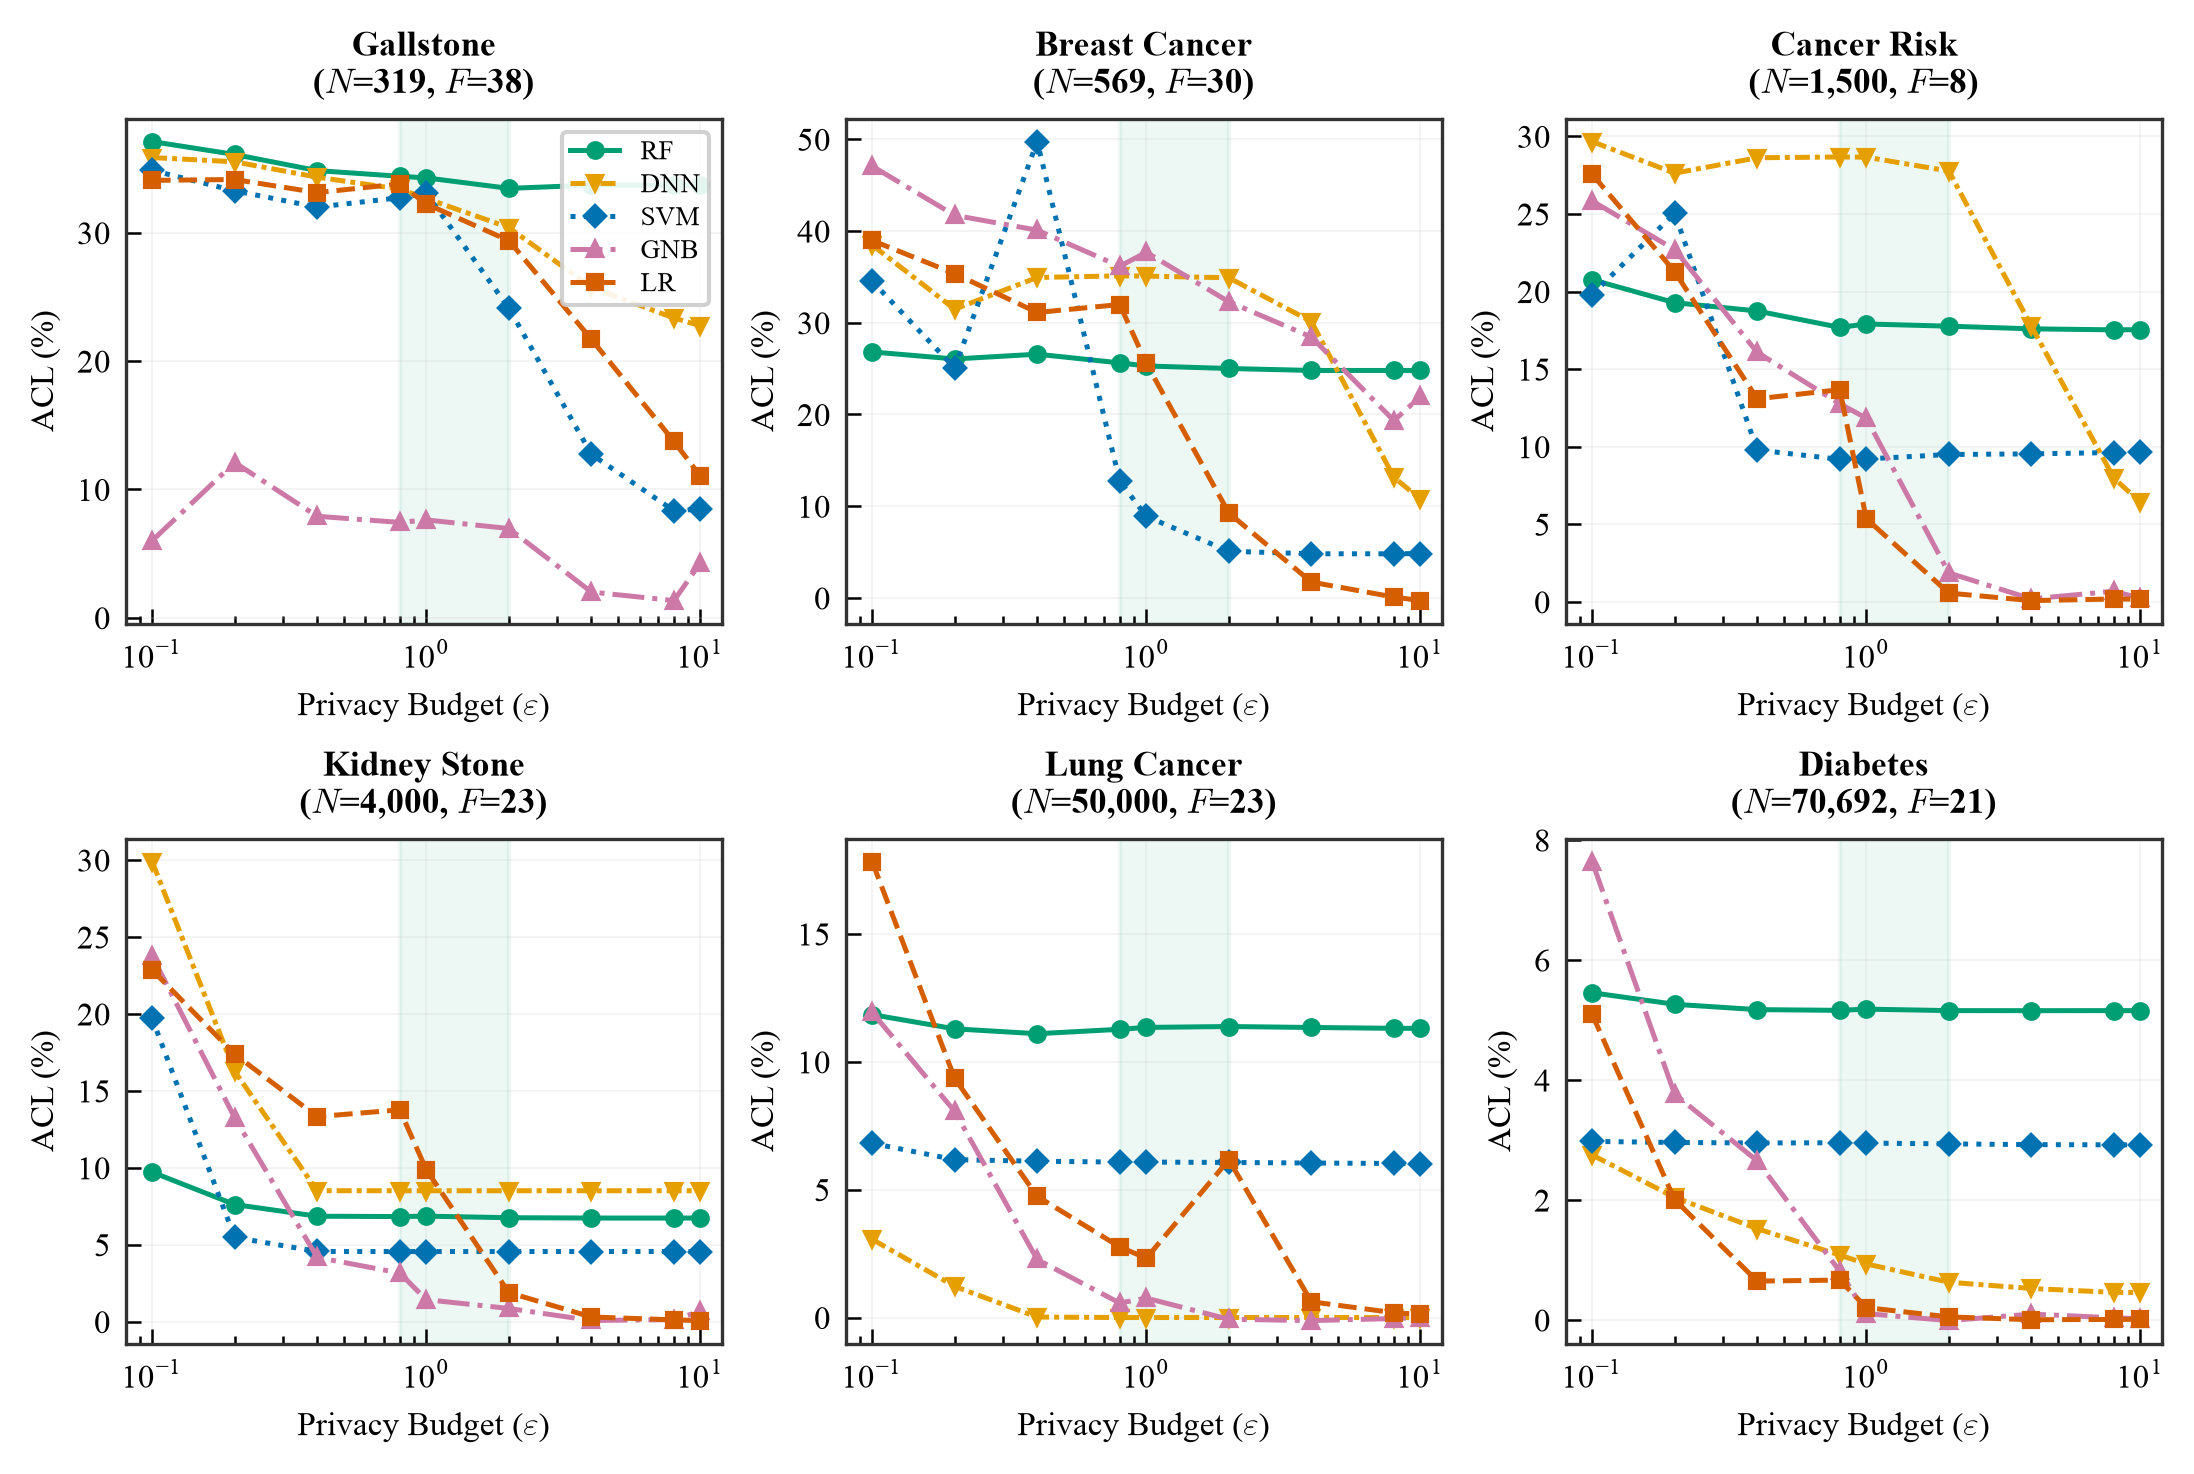

Saved: fig1_faceted_line_chart_acl.pdf / .png


In [4]:
# Colorblind-friendly palette (Tol's vibrant scheme — distinguishable in grayscale and by colorblind readers)
MODEL_COLORS = {
    'DP-RF': '#009E73',   # Bluish green
    'DP-LR': '#D55E00',   # Vermillion
    'DP-GNB': '#CC79A7',  # Reddish purple
    'DP-SVM': '#0072B2',  # Blue
    'DP-DNN': '#E69F00',  # Orange
}

MODEL_MARKERS = {
    'DP-RF': 'o',
    'DP-LR': 's',
    'DP-GNB': '^',
    'DP-SVM': 'D',
    'DP-DNN': 'v',
}

MODEL_LINESTYLES = {
    'DP-RF': '-',
    'DP-LR': '--',
    'DP-GNB': '-.',
    'DP-SVM': ':',
    'DP-DNN': (0, (3, 1, 1, 1)),
}

# Display labels without the repeated 'DP-' prefix; the DP framing is stated once
# in each figure's heading instead.
MODEL_SHORT = {'DP-RF': 'RF', 'DP-LR': 'LR', 'DP-GNB': 'GNB', 'DP-SVM': 'SVM', 'DP-DNN': 'DNN'}

# Ordered by sample count ascending (Gallstone smallest -> Diabetes largest), 3 per row.
datasets_list = sorted(datasets_all, key=lambda d: DATASET_N_SAMPLES[d])

fig, axes = plt.subplots(2, 3, figsize=(7.2, 4.8))
axes = axes.flatten()

for idx, dataset in enumerate(datasets_list):
    ax = axes[idx]
    ds_data = df_common[df_common['dataset'] == dataset]
    
    for model in ['DP-RF', 'DP-DNN', 'DP-SVM', 'DP-GNB', 'DP-LR']:
        model_data = ds_data[ds_data['model'] == model].sort_values('epsilon')
        if model_data.empty:
            continue
        ax.plot(
            model_data['epsilon'], model_data['ACL'] * 100,
            color=MODEL_COLORS[model],
            marker=MODEL_MARKERS[model],
            linestyle=MODEL_LINESTYLES[model],
            markersize=3.5, linewidth=1.2, label=MODEL_SHORT[model]
        )
    
    n = DATASET_N_SAMPLES.get(dataset, 0)
    f = DATASET_FEATURES.get(dataset, '?')
    ax.set_title(f"{dataset}\n($N$={n:,}, $F$={f})", fontsize=8.5, fontweight='bold')
    ax.set_xlabel(r'Privacy Budget ($\varepsilon$)', fontsize=8)
    ax.set_ylabel('ACL (%)', fontsize=8)
    ax.set_xscale('log')
    ax.set_xlim(0.08, 12)
    ax.grid(True, alpha=0.25, linestyle='-', color='#cccccc')
    ax.axvspan(0.8, 2.0, alpha=0.07, color='#009E73', zorder=0)
    
    if idx == 0:
        ax.legend(loc='upper right', fontsize=6.5, handlelength=1.8, borderpad=0.3, labelspacing=0.3)
plt.savefig(FIG_DIR / 'fig1_faceted_line_chart_acl.pdf', format='pdf', bbox_inches='tight')
plt.savefig(FIG_DIR / 'fig1_faceted_line_chart_acl.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig1_faceted_line_chart_acl.pdf / .png")

---
## 3. ACL Heatmap: Model × Dataset at Key Epsilon Values

Heatmaps showing ACL (%) for each model-dataset combination at selected privacy budgets. Lower ACL = better utility preservation.

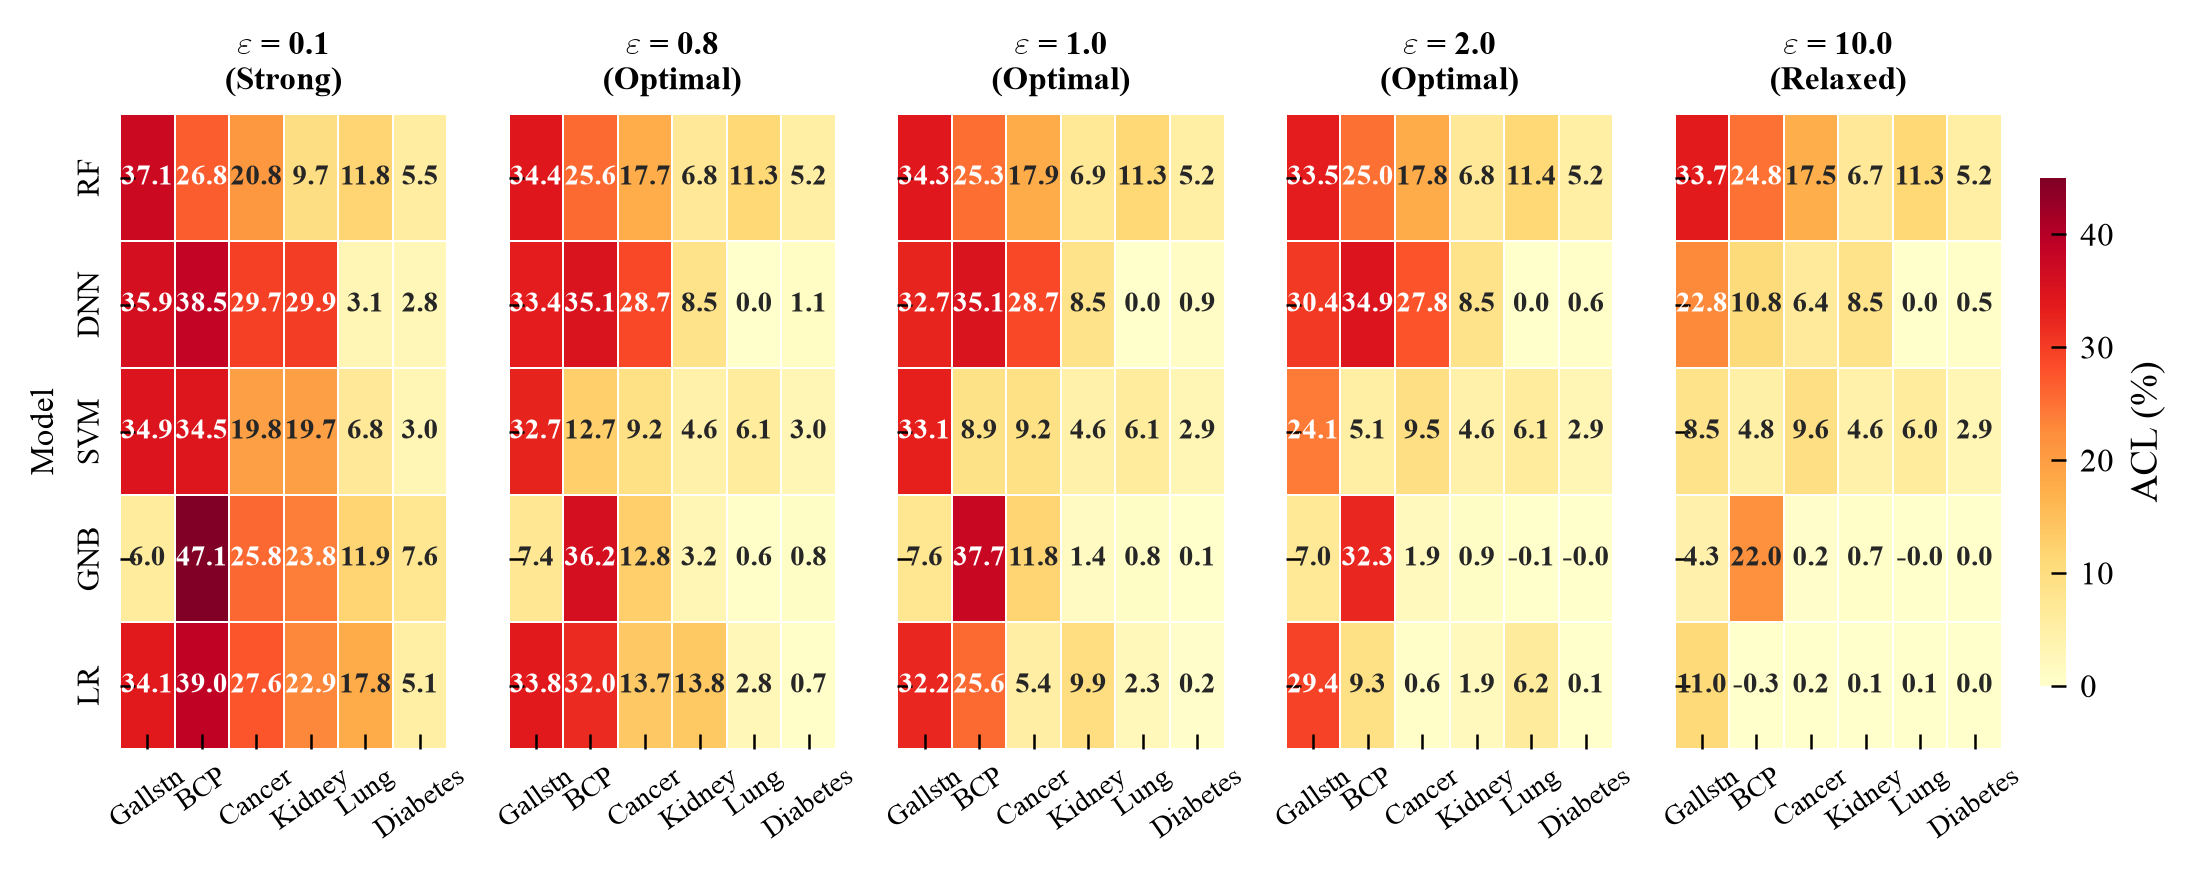

Saved: fig2_acl_heatmap_by_epsilon.pdf / .png


In [5]:
HEATMAP_EPSILONS = [0.1, 0.8, 1.0, 2.0, 10.0]

fig, axes = plt.subplots(1, len(HEATMAP_EPSILONS), figsize=(7.2, 2.8), sharey=True)

# Sequential colormap that works in grayscale (light = good, dark = bad)
cmap = sns.color_palette("YlOrRd", as_cmap=True)

for idx, eps in enumerate(HEATMAP_EPSILONS):
    ax = axes[idx]
    eps_data = df_common[df_common['epsilon'] == eps]
    
    pivot = eps_data.pivot_table(
        index='model', columns='dataset', values='ACL', aggfunc='mean'
    ) * 100
    
    model_order = ['DP-RF', 'DP-DNN', 'DP-SVM', 'DP-GNB', 'DP-LR']
    pivot = pivot.reindex(index=[m for m in model_order if m in pivot.index])
    pivot = pivot.reindex(columns=[d for d in datasets_list if d in pivot.columns])
    
    # Abbreviated dataset names for space
    short_names = {'Breast Cancer': 'BCP', 'Cancer Risk': 'Cancer', 'Diabetes': 'Diabetes',
                   'Gallstone': 'Gallstn', 'Kidney Stone': 'Kidney', 'Lung Cancer': 'Lung'}
    pivot.columns = [short_names.get(c, c) for c in pivot.columns]
    pivot.index = [MODEL_SHORT.get(m, m) for m in pivot.index]
    
    sns.heatmap(
        pivot, annot=True, fmt='.1f', cmap=cmap,
        vmin=0, vmax=45, ax=ax, cbar=(idx == len(HEATMAP_EPSILONS) - 1),
        linewidths=0.4, linecolor='white',
        annot_kws={'size': 7, 'weight': 'bold'},
        cbar_kws={'label': 'ACL (%)', 'shrink': 0.8} if idx == len(HEATMAP_EPSILONS) - 1 else {}
    )
    
    label = 'Strong' if eps <= 0.1 else ('Optimal' if 0.8 <= eps <= 2.0 else 'Relaxed')
    ax.set_title(f'$\\varepsilon$ = {eps}\n({label})', fontsize=8, fontweight='bold')
    ax.set_xlabel('')
    if idx == 0:
        ax.set_ylabel('Model', fontsize=8)
    else:
        ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=35, labelsize=7)
    ax.tick_params(axis='y', labelsize=7.5)
plt.savefig(FIG_DIR / 'fig2_acl_heatmap_by_epsilon.pdf', format='pdf', bbox_inches='tight')
plt.savefig(FIG_DIR / 'fig2_acl_heatmap_by_epsilon.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig2_acl_heatmap_by_epsilon.pdf / .png")

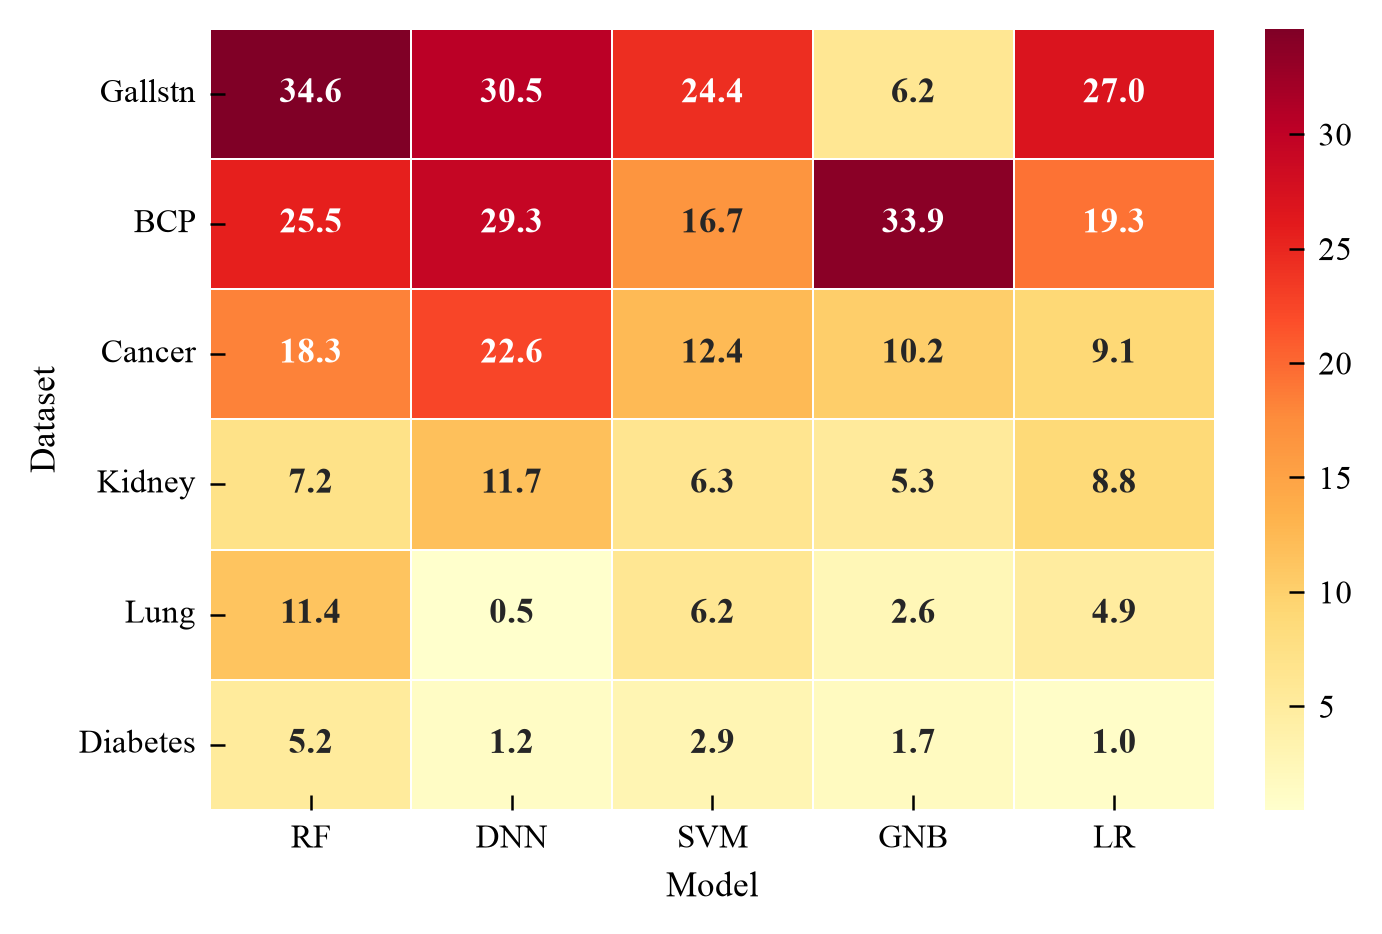

Saved: fig2b_acl_heatmap_average.pdf / .png


In [6]:
# Single comprehensive heatmap: Average ACL across all epsilon values
fig, ax = plt.subplots(figsize=(4.5, 3.0))

# Dataset on the y-axis (rows), model on the x-axis (columns).
avg_acl = df_common.groupby(['dataset', 'model'])['ACL'].mean().unstack() * 100

model_order = ['DP-RF', 'DP-DNN', 'DP-SVM', 'DP-GNB', 'DP-LR']
avg_acl = avg_acl.reindex(index=[d for d in datasets_list if d in avg_acl.index])
avg_acl = avg_acl.reindex(columns=[m for m in model_order if m in avg_acl.columns])

short_names = {'Breast Cancer': 'BCP', 'Cancer Risk': 'Cancer', 'Diabetes': 'Diabetes',
               'Gallstone': 'Gallstn', 'Kidney Stone': 'Kidney', 'Lung Cancer': 'Lung'}
avg_acl.index = [short_names.get(d, d) for d in avg_acl.index]
avg_acl.columns = [MODEL_SHORT.get(m, m) for m in avg_acl.columns]

sns.heatmap(
    avg_acl, annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.4, linecolor='white', ax=ax,
    annot_kws={'size': 8.5, 'weight': 'bold'}
)
ax.set_xlabel('Model', fontsize=8.5)
ax.set_ylabel('Dataset', fontsize=8.5)
ax.tick_params(axis='x', rotation=0, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=8)

plt.savefig(FIG_DIR / 'fig2b_acl_heatmap_average.pdf', format='pdf', bbox_inches='tight')
plt.savefig(FIG_DIR / 'fig2b_acl_heatmap_average.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig2b_acl_heatmap_average.pdf / .png")

---
## 4. Privacy-Utility Trade-off Curves

Accuracy vs ε curves overlaid across datasets, showing how dataset size (N) impacts the trade-off. Larger datasets achieve better utility at the same privacy budget.

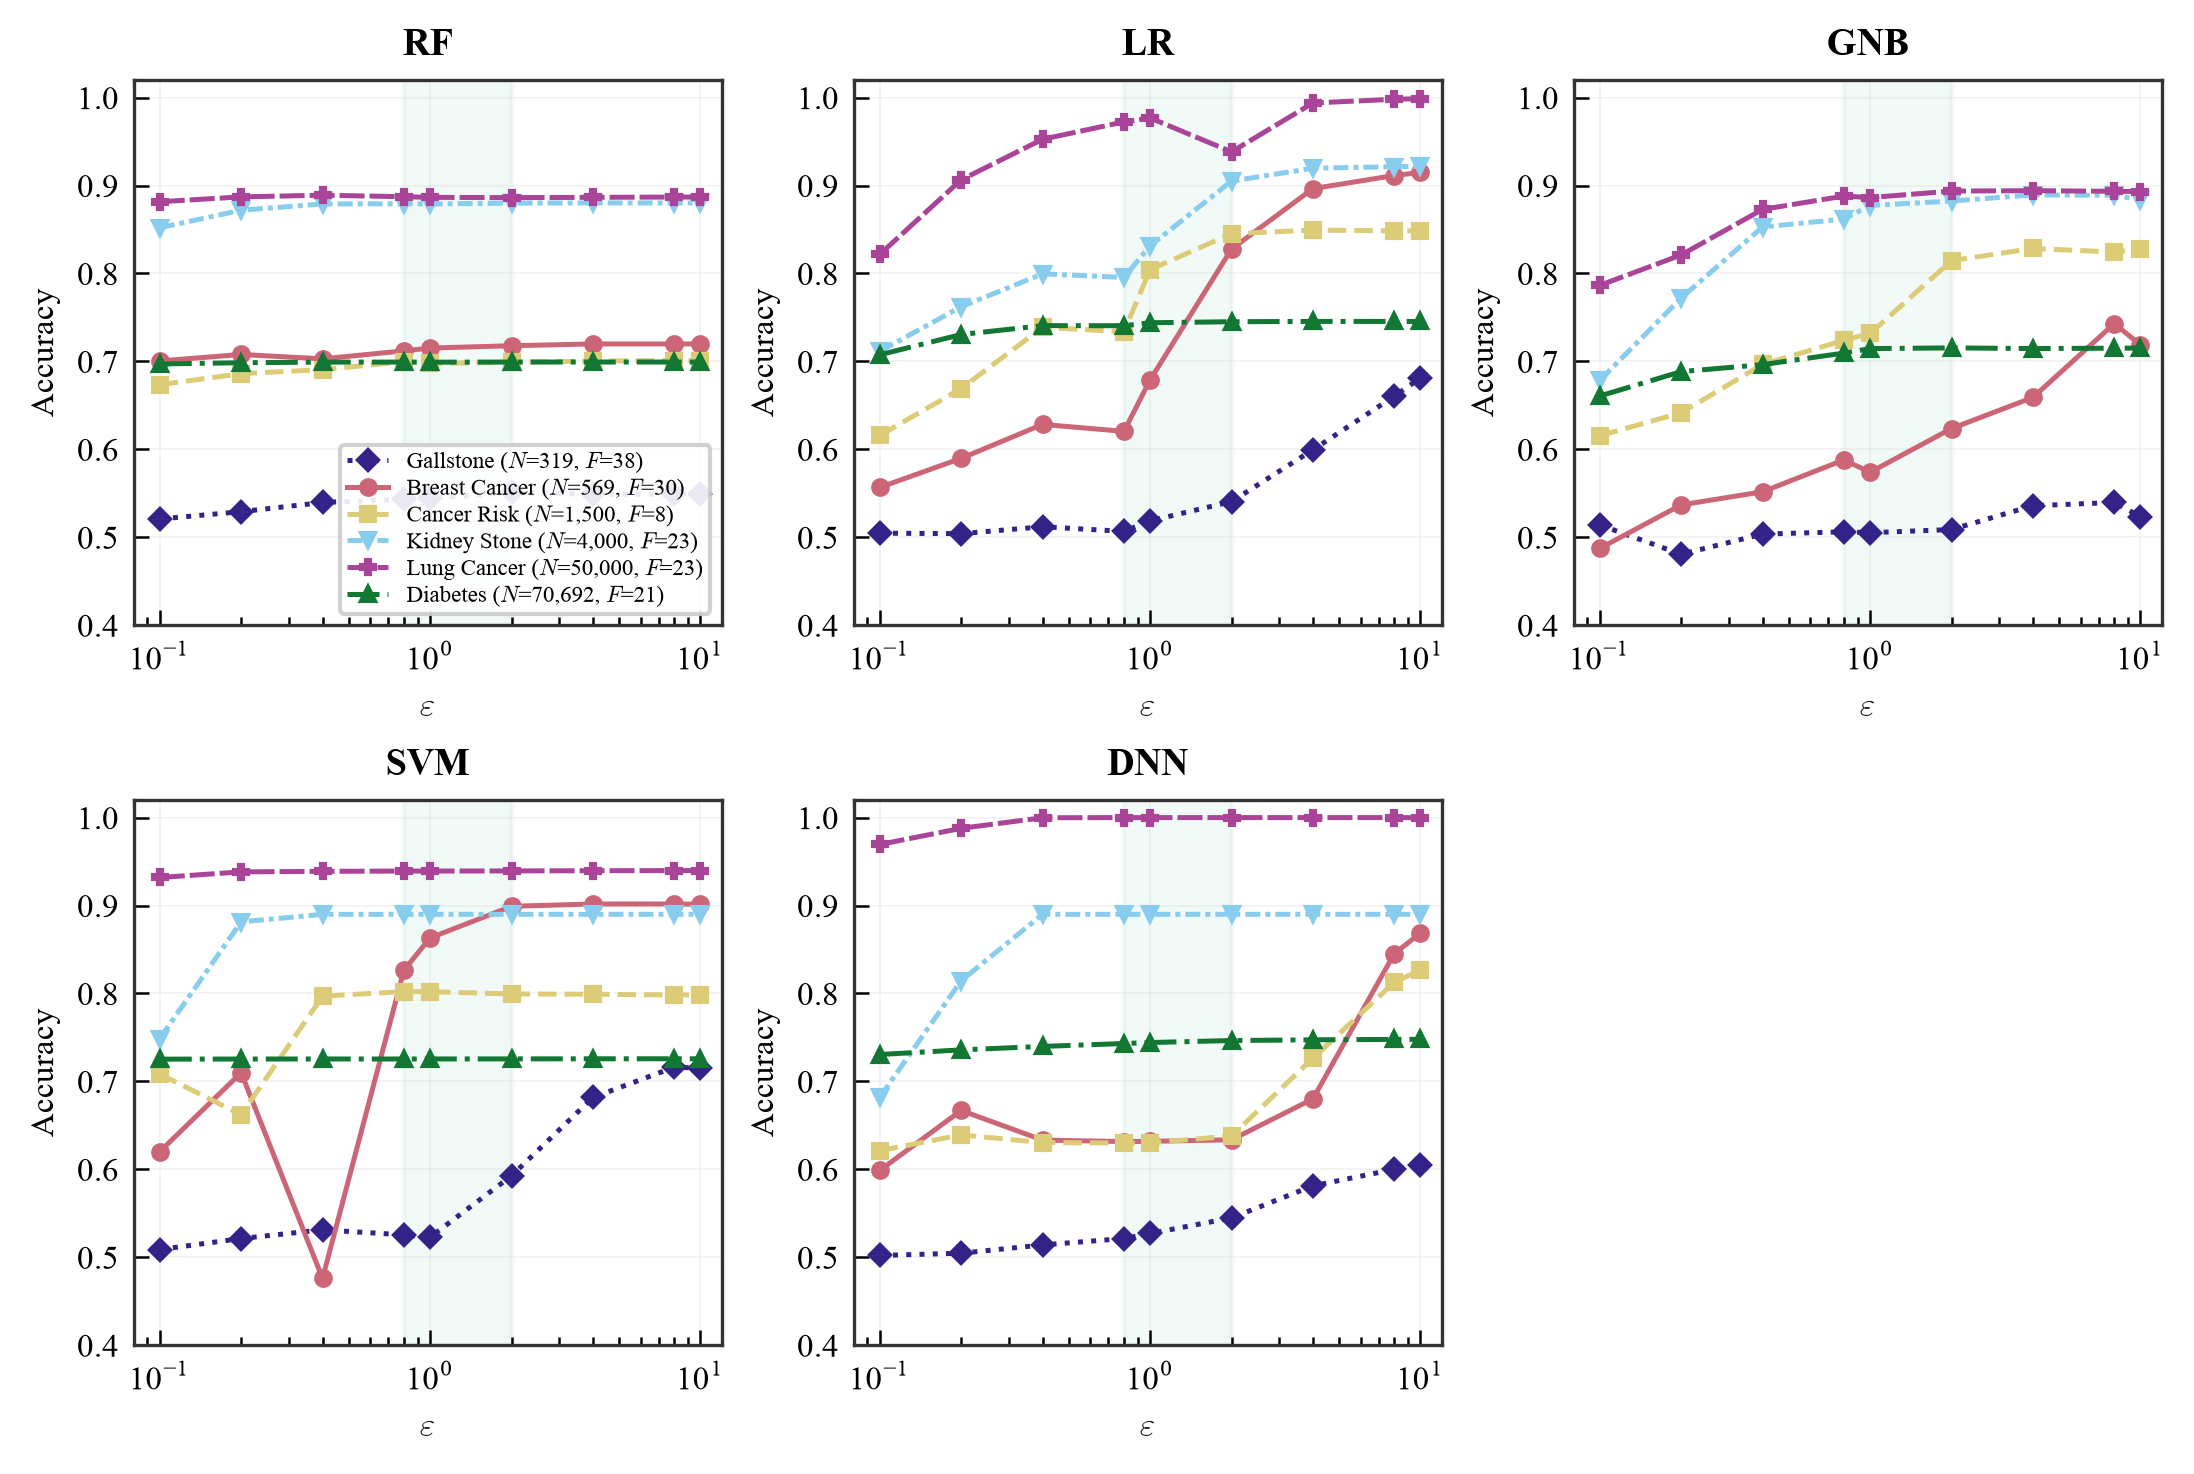

Saved: fig3_privacy_utility_tradeoff.pdf / .png


In [7]:
# Colorblind-friendly dataset palette (Paul Tol's muted scheme)
DATASET_COLORS = {
    'Breast Cancer': '#CC6677',   # Rose
    'Cancer Risk': '#DDCC77',     # Sand
    'Diabetes': '#117733',        # Green
    'Gallstone': '#332288',       # Indigo
    'Kidney Stone': '#88CCEE',    # Cyan
    'Lung Cancer': '#AA4499',     # Purple
}

DATASET_LINESTYLES = {
    'Breast Cancer': '-',
    'Cancer Risk': '--',
    'Diabetes': '-.',
    'Gallstone': ':',
    'Kidney Stone': (0, (3, 1, 1, 1)),
    'Lung Cancer': (0, (5, 1)),
}

DATASET_MARKERS = {
    'Breast Cancer': 'o',
    'Cancer Risk': 's',
    'Diabetes': '^',
    'Gallstone': 'D',
    'Kidney Stone': 'v',
    'Lung Cancer': 'P',
}

fig, axes = plt.subplots(2, 3, figsize=(7.2, 4.8))
axes = axes.flatten()

models_list = ['DP-RF', 'DP-LR', 'DP-GNB', 'DP-SVM', 'DP-DNN']

for idx, model in enumerate(models_list):
    ax = axes[idx]
    model_data = df_common[df_common['model'] == model]
    
    for dataset in datasets_list:
        ds_data = model_data[model_data['dataset'] == dataset].sort_values('epsilon')
        if ds_data.empty:
            continue
        n = DATASET_N_SAMPLES.get(dataset, 0)
        f = DATASET_FEATURES.get(dataset, '?')
        ax.plot(
            ds_data['epsilon'], ds_data['accuracy'],
            color=DATASET_COLORS[dataset],
            linestyle=DATASET_LINESTYLES[dataset],
            marker=DATASET_MARKERS[dataset],
            markersize=3.5, linewidth=1.2,
            label=f"{dataset} ($N$={n:,}, $F$={f})"
        )
    
    ax.set_title(MODEL_SHORT[model], fontweight='bold', fontsize=9)
    ax.set_xlabel(r'$\varepsilon$', fontsize=8)
    ax.set_ylabel('Accuracy', fontsize=8)
    ax.set_xscale('log')
    ax.set_xlim(0.08, 12)
    ax.set_ylim(0.4, 1.02)
    ax.grid(True, alpha=0.25, linestyle='-', color='#cccccc')
    ax.axvspan(0.8, 2.0, alpha=0.05, color='#009E73', zorder=0)
    
    if idx == 0:
        ax.legend(loc='lower right', fontsize=5.5, handlelength=1.8, borderpad=0.3, labelspacing=0.25)

axes[5].set_visible(False)
plt.savefig(FIG_DIR / 'fig3_privacy_utility_tradeoff.pdf', format='pdf', bbox_inches='tight')
plt.savefig(FIG_DIR / 'fig3_privacy_utility_tradeoff.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig3_privacy_utility_tradeoff.pdf / .png")

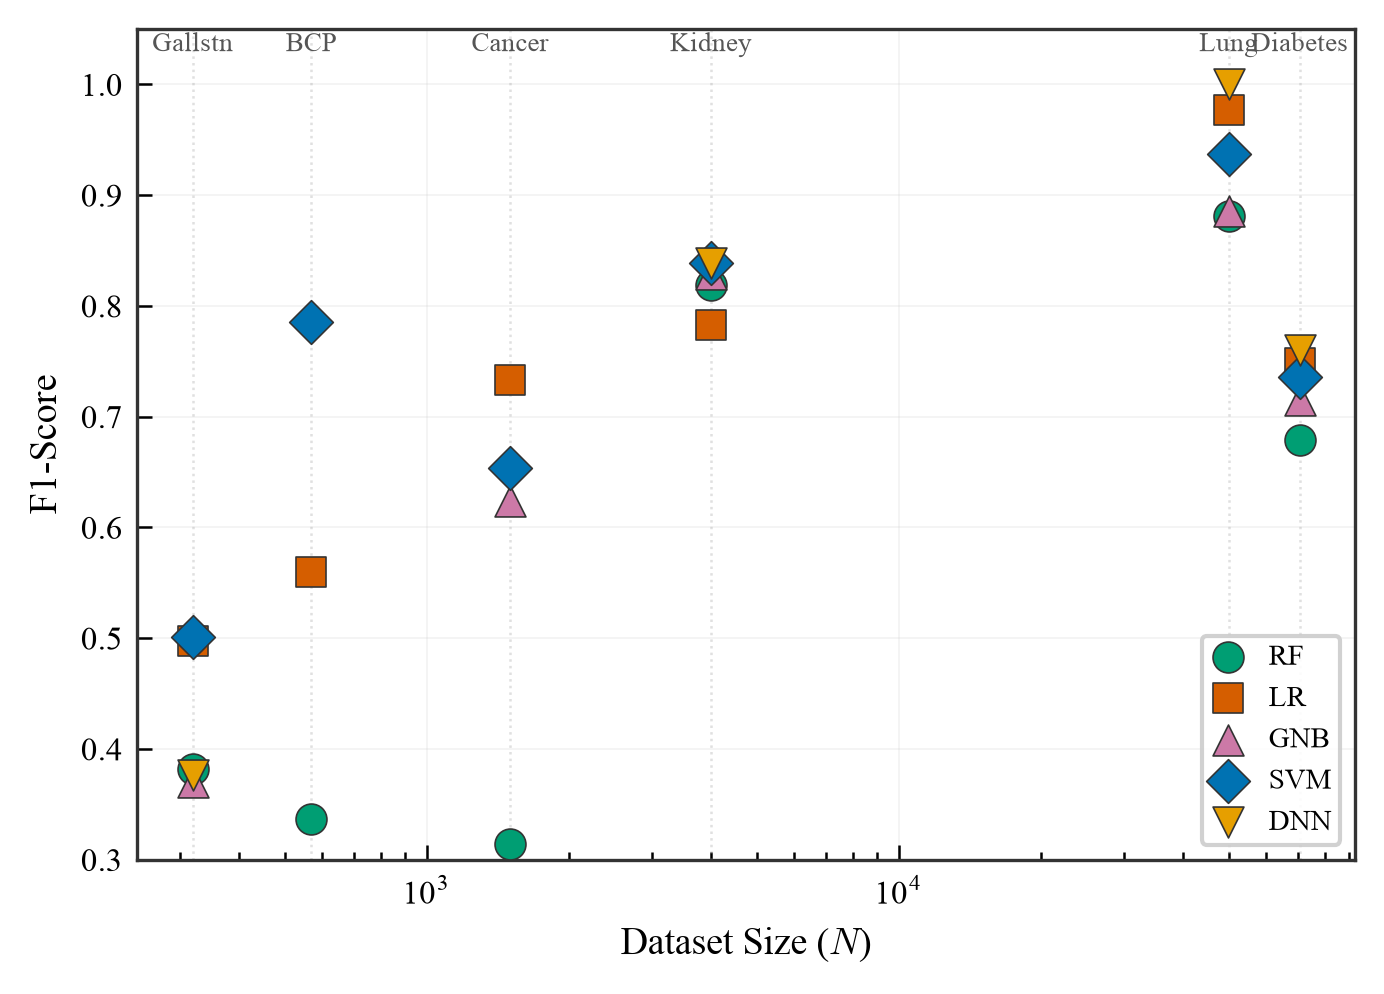

Saved: fig3b_f1_vs_datasize.pdf / .png


In [8]:
# Consolidated privacy-utility trade-off: F1 Score at ε=1.0 vs Dataset Size
fig, ax = plt.subplots(figsize=(4.5, 3.2))

eps_target = 1.0
trade_data = df_common[df_common['epsilon'] == eps_target].copy()

for model in models_list:
    m_data = trade_data[trade_data['model'] == model]
    if m_data.empty:
        continue
    ax.scatter(
        m_data['n_samples'], m_data['f1_score'],
        c=MODEL_COLORS[model], marker=MODEL_MARKERS[model],
        s=55, label=MODEL_SHORT[model], edgecolors='#333333', linewidth=0.4, zorder=5
    )

ax.set_xscale('log')
ax.set_xlabel('Dataset Size ($N$)', fontsize=9)
ax.set_ylabel('F1-Score', fontsize=9)
ax.grid(True, alpha=0.25, linestyle='-', color='#cccccc')
ax.legend(fontsize=7, loc='lower right', handlelength=1.2, borderpad=0.3)
ax.set_ylim(0.3, 1.05)

# Annotate datasets with vertical lines
short = {'Breast Cancer': 'BCP', 'Cancer Risk': 'Cancer', 'Diabetes': 'Diabetes',
         'Gallstone': 'Gallstn', 'Kidney Stone': 'Kidney', 'Lung Cancer': 'Lung'}
for dataset in datasets_list:
    n = DATASET_N_SAMPLES.get(dataset, 0)
    ax.axvline(n, color='#999999', alpha=0.3, linestyle=':', linewidth=0.6)
    ax.text(n, 1.03, short.get(dataset, dataset), ha='center', fontsize=6.5, color='#555555')

plt.savefig(FIG_DIR / 'fig3b_f1_vs_datasize.pdf', format='pdf', bbox_inches='tight')
plt.savefig(FIG_DIR / 'fig3b_f1_vs_datasize.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig3b_f1_vs_datasize.pdf / .png")

---
## 5. Model Ranking Map

Rank each model by ACL (lower = better rank) at each epsilon value across datasets. Shows which model consistently performs best under DP constraints.

In [9]:
# Compute rankings: for each (dataset, epsilon), rank models by ACL (lower ACL = rank 1)
df_ranked = df_common.copy()
df_ranked['rank'] = df_ranked.groupby(['dataset', 'epsilon'])['ACL'].rank(method='min')

# Average rank per model across all datasets and epsilons
avg_rank = df_ranked.groupby('model')['rank'].mean().sort_values()
print("Overall Model Rankings (lower = better):")
for model, rank in avg_rank.items():
    print(f"  {model:8s}: {rank:.2f}")
print()

Overall Model Rankings (lower = better):
  DP-GNB  : 2.33
  DP-LR   : 2.52
  DP-SVM  : 2.70
  DP-DNN  : 3.43
  DP-RF   : 4.02



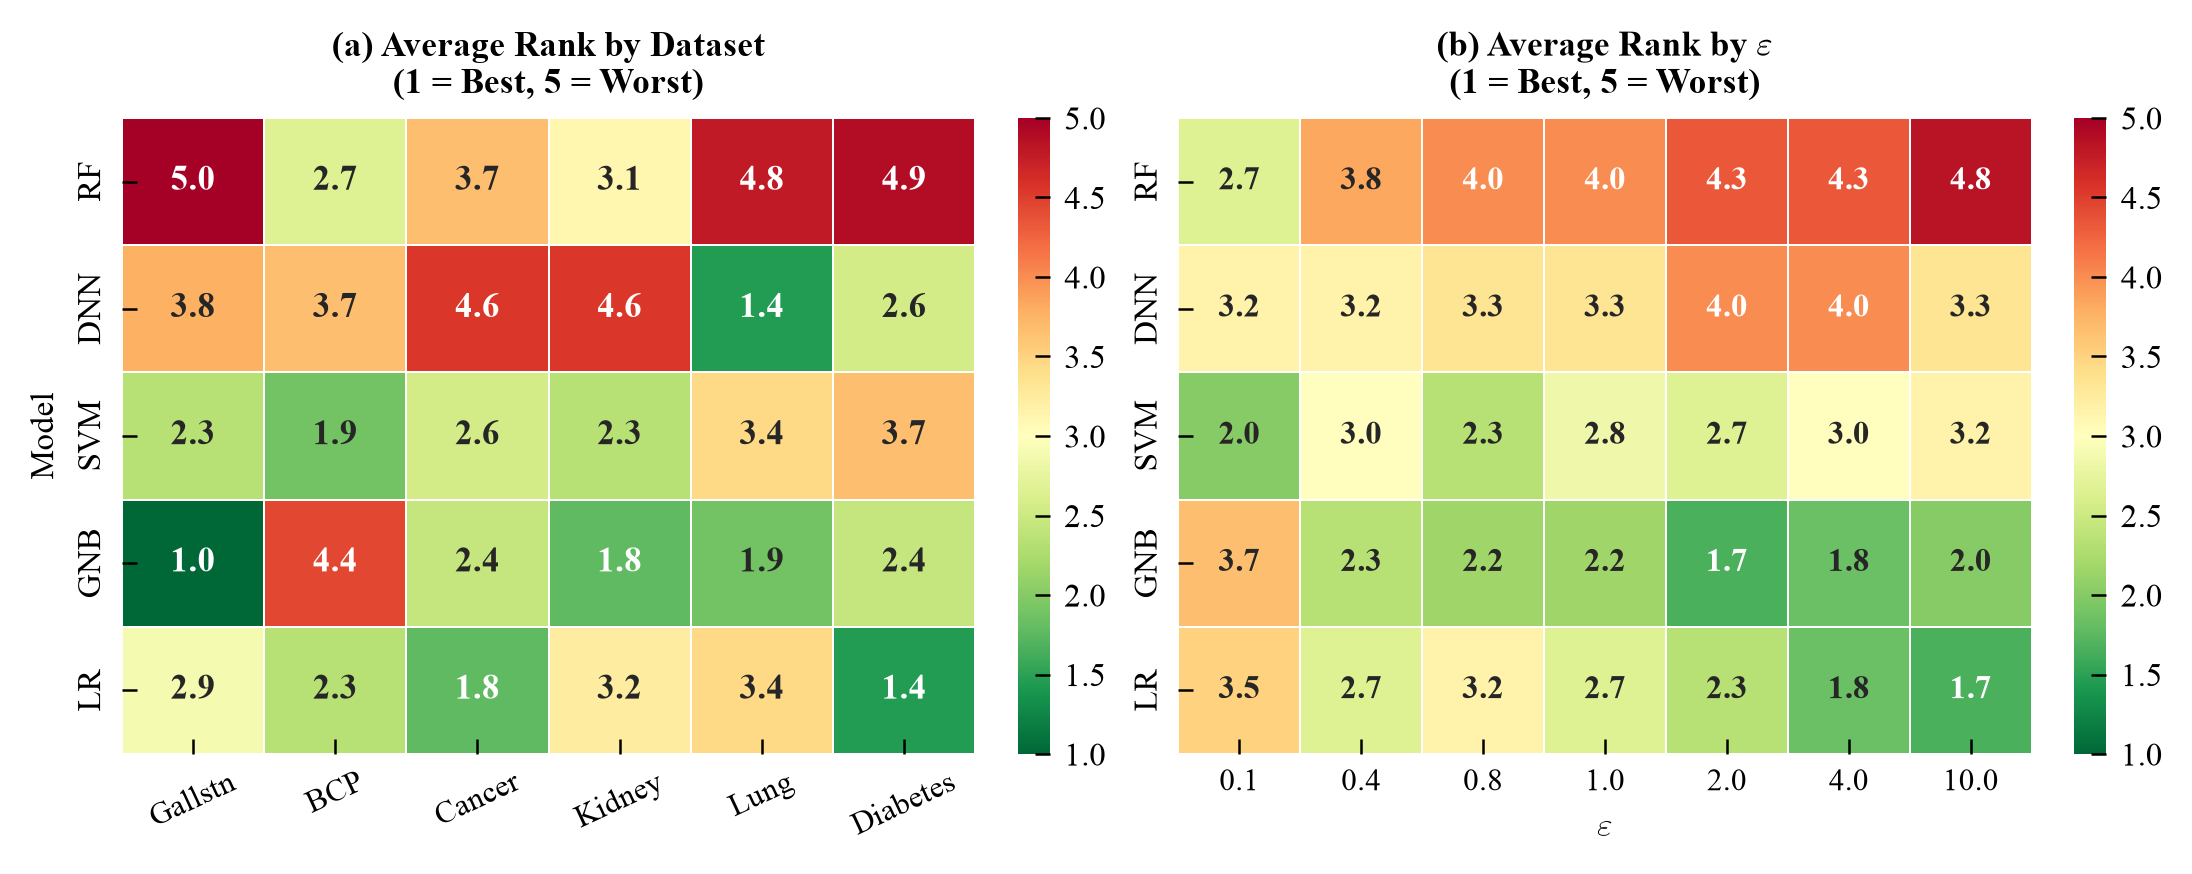

Saved: fig4_model_ranking_map.pdf / .png


In [10]:
# Ranking heatmap: Model rank per dataset (averaged over all ε)
fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.8))

# Custom diverging colormap: green (rank 1) → yellow → red (rank 5)
rank_cmap = sns.color_palette("RdYlGn_r", as_cmap=True)

# Left: Average rank by dataset
ax = axes[0]
rank_by_dataset = df_ranked.groupby(['model', 'dataset'])['rank'].mean().unstack()
rank_by_dataset = rank_by_dataset.reindex(index=[m for m in model_order if m in rank_by_dataset.index])
rank_by_dataset = rank_by_dataset.reindex(columns=[d for d in datasets_list if d in rank_by_dataset.columns])

short_names = {'Breast Cancer': 'BCP', 'Cancer Risk': 'Cancer', 'Diabetes': 'Diabetes',
               'Gallstone': 'Gallstn', 'Kidney Stone': 'Kidney', 'Lung Cancer': 'Lung'}
rank_by_dataset.columns = [short_names.get(c, c) for c in rank_by_dataset.columns]
rank_by_dataset.index = [MODEL_SHORT.get(m, m) for m in rank_by_dataset.index]

sns.heatmap(
    rank_by_dataset, annot=True, fmt='.1f', cmap=rank_cmap,
    vmin=1, vmax=5, ax=ax, linewidths=0.4, linecolor='white',
    annot_kws={'size': 8.5, 'weight': 'bold'}
)
ax.set_title('(a) Average Rank by Dataset\n(1 = Best, 5 = Worst)', fontweight='bold', fontsize=8.5)
ax.set_xlabel('')
ax.set_ylabel('Model', fontsize=8)
ax.tick_params(axis='x', rotation=25, labelsize=7.5)
ax.tick_params(axis='y', labelsize=8)

# Right: Average rank by epsilon
ax = axes[1]
RANK_EPSILONS = [0.1, 0.4, 0.8, 1.0, 2.0, 4.0, 10.0]
rank_by_eps = df_ranked[df_ranked['epsilon'].isin(RANK_EPSILONS)].groupby(['model', 'epsilon'])['rank'].mean().unstack()
rank_by_eps = rank_by_eps.reindex(index=[m for m in model_order if m in rank_by_eps.index])
rank_by_eps.index = [MODEL_SHORT.get(m, m) for m in rank_by_eps.index]

sns.heatmap(
    rank_by_eps, annot=True, fmt='.1f', cmap=rank_cmap,
    vmin=1, vmax=5, ax=ax, linewidths=0.4, linecolor='white',
    annot_kws={'size': 8, 'weight': 'bold'}
)
ax.set_title(r'(b) Average Rank by $\varepsilon$' + '\n(1 = Best, 5 = Worst)', fontweight='bold', fontsize=8.5)
ax.set_xlabel(r'$\varepsilon$', fontsize=8)
ax.set_ylabel('')
ax.tick_params(axis='x', labelsize=7.5)
ax.tick_params(axis='y', labelsize=8)
plt.savefig(FIG_DIR / 'fig4_model_ranking_map.pdf', format='pdf', bbox_inches='tight')
plt.savefig(FIG_DIR / 'fig4_model_ranking_map.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig4_model_ranking_map.pdf / .png")

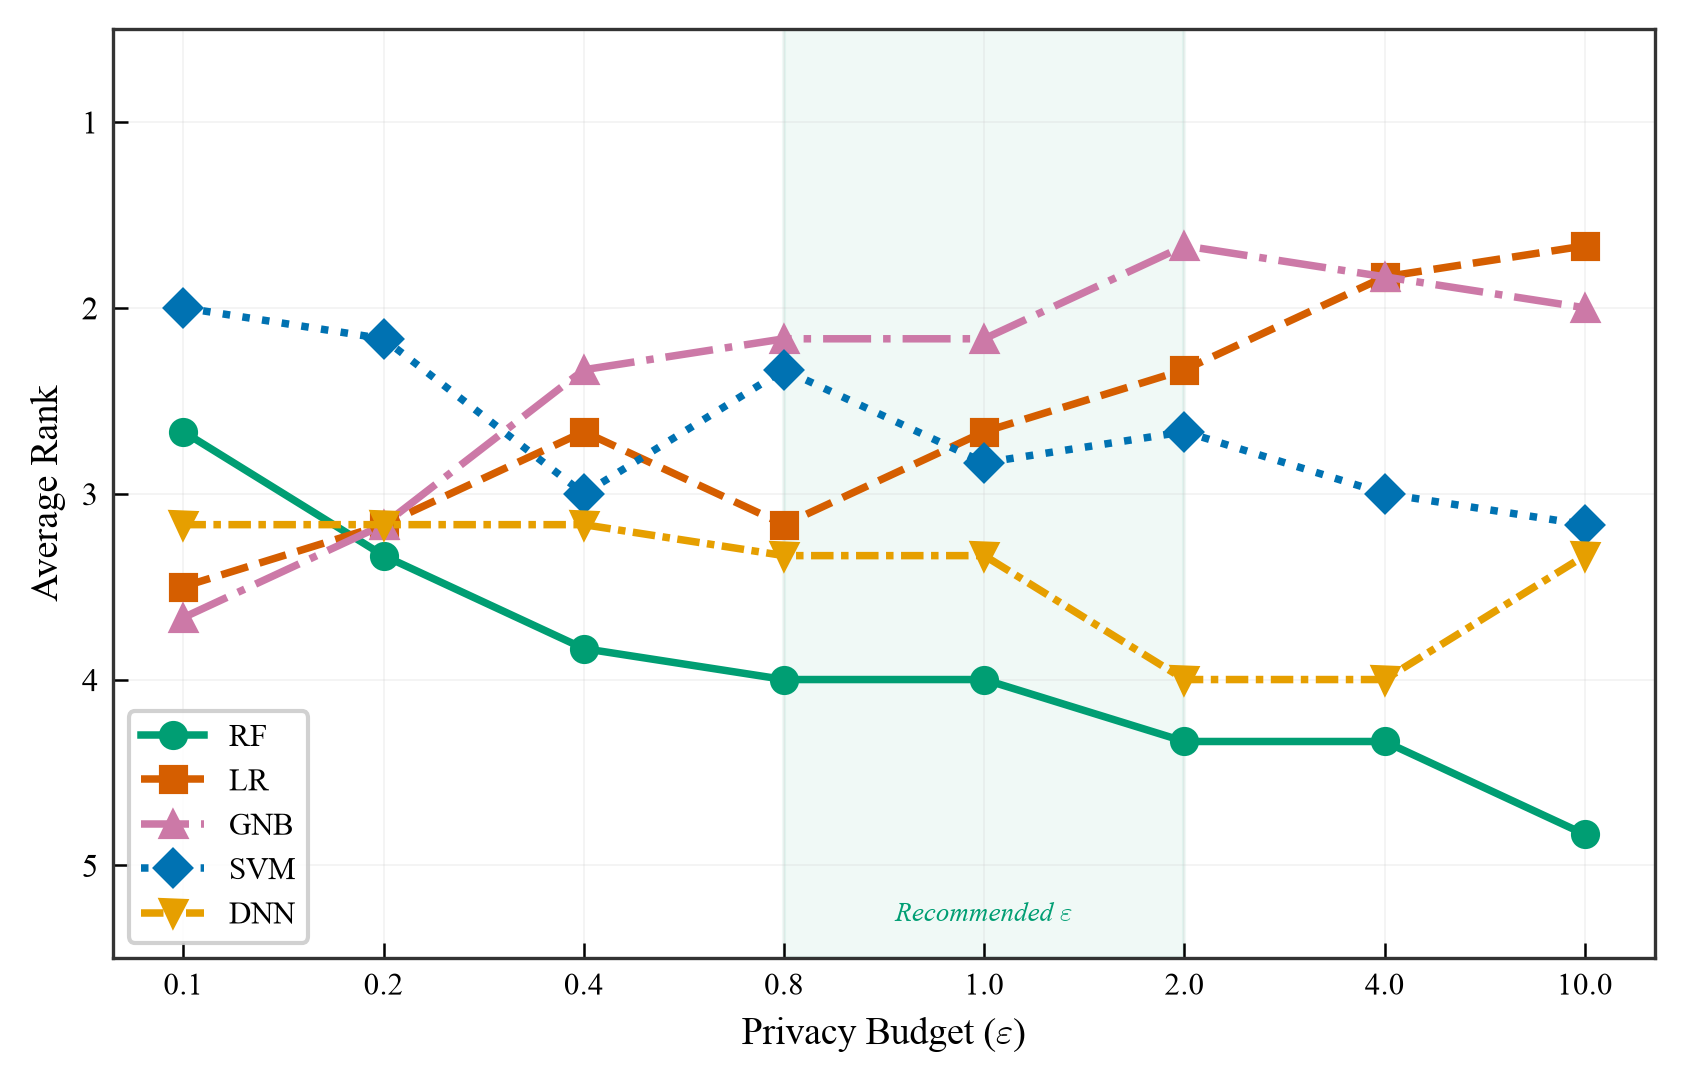

Saved: fig4b_ranking_bump_chart.pdf / .png


In [11]:
# Bump chart: rank trajectory across epsilon values
fig, ax = plt.subplots(figsize=(5.5, 3.5))

BUMP_EPSILONS = [0.1, 0.2, 0.4, 0.8, 1.0, 2.0, 4.0, 10.0]
bump_data = df_ranked[df_ranked['epsilon'].isin(BUMP_EPSILONS)].copy()
avg_rank_by_eps = bump_data.groupby(['model', 'epsilon'])['rank'].mean().reset_index()

for model in models_list:
    m_data = avg_rank_by_eps[avg_rank_by_eps['model'] == model].sort_values('epsilon')
    if m_data.empty:
        continue
    ax.plot(
        range(len(m_data)), m_data['rank'].values,
        color=MODEL_COLORS[model], marker=MODEL_MARKERS[model],
        linestyle=MODEL_LINESTYLES[model],
        markersize=6, linewidth=1.8, label=MODEL_SHORT[model]
    )

ax.set_xticks(range(len(BUMP_EPSILONS)))
ax.set_xticklabels([str(e) for e in BUMP_EPSILONS], fontsize=7.5)
ax.set_xlabel(r'Privacy Budget ($\varepsilon$)', fontsize=9)
ax.set_ylabel('Average Rank', fontsize=9)
ax.invert_yaxis()
ax.set_ylim(5.5, 0.5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.grid(True, alpha=0.25, linestyle='-', color='#cccccc')
ax.legend(loc='lower left', fontsize=7.5, handlelength=2.0, borderpad=0.4)

# Highlight recommended range
ax.axvspan(3, 5, alpha=0.06, color='#009E73', zorder=0)
ax.text(4, 5.3, r'Recommended $\varepsilon$', fontsize=6.5, ha='center', color='#009E73', style='italic')

plt.savefig(FIG_DIR / 'fig4b_ranking_bump_chart.pdf', format='pdf', bbox_inches='tight')
plt.savefig(FIG_DIR / 'fig4b_ranking_bump_chart.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig4b_ranking_bump_chart.pdf / .png")

---
## 6. Summary Statistics

In [12]:
# Summary table: Best model per dataset at ε=1.0
eps_summary = df_common[df_common['epsilon'] == 1.0].copy()
best_per_dataset = eps_summary.loc[eps_summary.groupby('dataset')['ACL'].idxmin()]

print("=" * 72)
print(f"{'BEST MODEL PER DATASET AT ε = 1.0':^72}")
print("=" * 72)
print(f"  {'Dataset':<20s}   {'Model':<8s}   {'ACL(%)':>7s}   {'F1':>6s}   {'Accuracy':>8s}")
print("-" * 72)
for _, row in best_per_dataset.iterrows():
    print(f"  {row['dataset']:<20s}   {row['model']:<8s}   {row['ACL']*100:>6.2f}%   {row['f1_score']:>6.3f}   {row['accuracy']:>8.3f}")

print("\n" + "=" * 72)
print(f"{'OVERALL MODEL RANKINGS (Mean ACL across all ε and datasets)':^72}")
print("=" * 72)
overall = df_common.groupby('model').agg(
    mean_ACL=('ACL', 'mean'),
    mean_F1=('f1_score', 'mean'),
    mean_accuracy=('accuracy', 'mean'),
).sort_values('mean_ACL')

print(f"  {'Rank':<5s} {'Model':<8s}   {'Mean ACL(%)':>11s}   {'Mean F1':>8s}   {'Mean Acc':>8s}")
print("-" * 72)
for i, (model, row) in enumerate(overall.iterrows(), 1):
    print(f"  #{i:<4d} {model:<8s}   {row['mean_ACL']*100:>10.2f}%   {row['mean_F1']:>8.3f}   {row['mean_accuracy']:>8.3f}")

print("\n" + "=" * 72)
print("OUTPUT FILES:")
print("-" * 72)
print("  fig1_faceted_line_chart_acl.pdf    — ACL vs ε faceted by dataset")
print("  fig2_acl_heatmap_by_epsilon.pdf    — ACL heatmap at key ε values")
print("  fig2b_acl_heatmap_average.pdf      — Mean ACL heatmap (all ε)")
print("  fig3_privacy_utility_tradeoff.pdf  — Accuracy vs ε by model")
print("  fig3b_f1_vs_datasize.pdf           — F1 at ε=1.0 vs dataset size")
print("  fig4_model_ranking_map.pdf         — Ranking heatmaps")
print("  fig4b_ranking_bump_chart.pdf       — Rank trajectory (bump chart)")
print("=" * 72)

                   BEST MODEL PER DATASET AT ε = 1.0                    
  Dataset                Model       ACL(%)       F1   Accuracy
------------------------------------------------------------------------
  Breast Cancer          DP-SVM       8.89%    0.786      0.863
  Cancer Risk            DP-LR        5.36%    0.733      0.804
  Diabetes               DP-GNB       0.11%    0.715      0.715
  Gallstone              DP-GNB       7.62%    0.370      0.505
  Kidney Stone           DP-GNB       1.43%    0.829      0.877
  Lung Cancer            DP-DNN       0.00%    1.000      1.000

      OVERALL MODEL RANKINGS (Mean ACL across all ε and datasets)       
  Rank  Model      Mean ACL(%)    Mean F1   Mean Acc
------------------------------------------------------------------------
  #1    DP-GNB           9.97%      0.609      0.714
  #2    DP-SVM          11.49%      0.729      0.782
  #3    DP-LR           11.69%      0.721      0.766
  #4    DP-DNN          15.96%      0.562      